<a href="https://colab.research.google.com/github/triaanandafh/Mk_Data-Mining/blob/main/Clustering_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
# Load data
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Kuliah/Data-mining/credit_data_sample.csv', sep=';')

#tampilkan 5 data pertama
df.head()

Mounted at /content/drive


,Age,Credit_amount,Duration,Employment_since,Purpose
0,25,2000,12,2,car
1,40,7000,48,5,business
2,35,3500,24,4,car
3,23,1200,10,1,furniture
4,52,9000,60,5,real_estate


In [ ]:
features = ['Age', 'Credit_amount', 'Duration', 'Employment_since']
X = df[features]

In [ ]:
# Standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

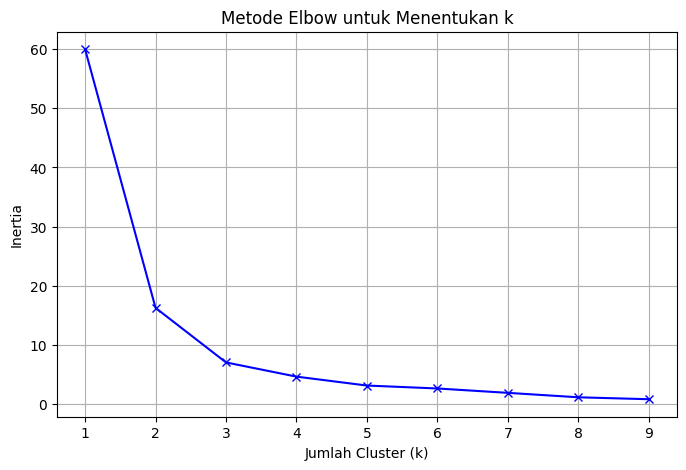

In [ ]:
# Elbow Method
inertia = []
K = range(1,10)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# plot hasil elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k')
plt.grid(True)
plt.show()

In [ ]:
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print(df.head())

   Age  Credit_amount  Duration  Employment_since      Purpose  Cluster
0   25           2000        12                 2          car        2
1   40           7000        48                 5     business        0
2   35           3500        24                 4          car        1
3   23           1200        10                 1    furniture        2
4   52           9000        60                 5  real_estate        0


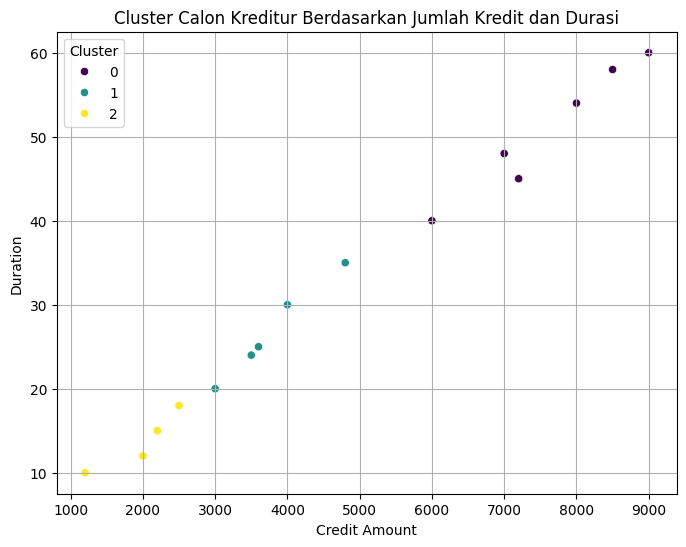

In [ ]:
# visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Credit_amount'], y=df['Duration'], hue=df['Cluster'], palette='viridis')
plt.title('Cluster Calon Kreditur Berdasarkan Jumlah Kredit dan Durasi')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.grid(True)
plt.show()


Silhouette Score:0.549
Inertia (k=3): 7.016


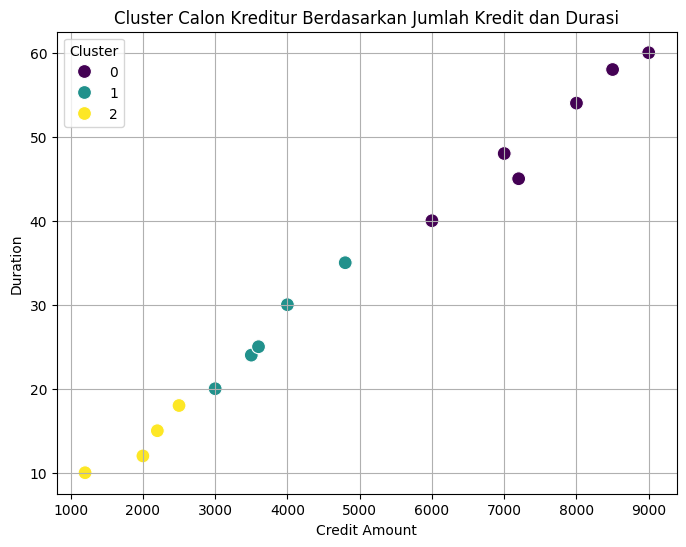

In [ ]:
# 7a. Hitung Silhoutte Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score:{silhouette_avg:.3f}")

# 7b. Tampilkan inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# step 8 - visualisasi haisl clustering (2 fitur: Credit_amount vs Duration)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Credit_amount'],
    y=df['Duration'],
    hue=df['Cluster'],
    palette='viridis',
    s=100)
plt.title('Cluster Calon Kreditur Berdasarkan Jumlah Kredit dan Durasi')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
# Load dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Memasukkan kolom label (species) sebagai fitur tambahan
df['species'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:
# Memilih semua kolom menjadi fitur X
X = df.copy()

# Melakukan standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

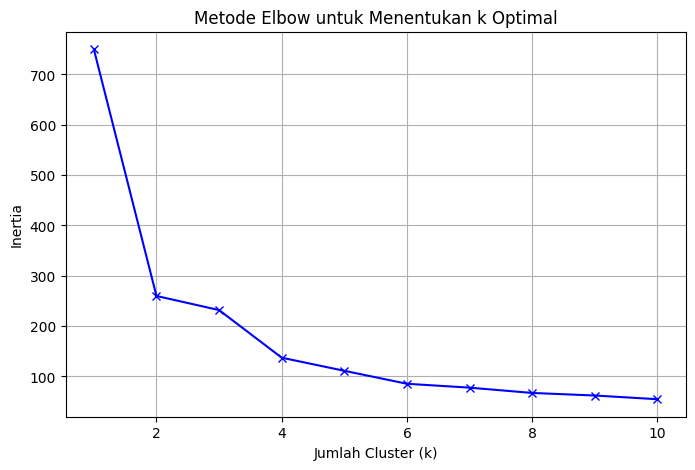

In [ ]:
# Inisialisasi list untuk menyimpan nilai inertia
inertia = []
K = range(1, 11)

# Perulangan untuk menghitung nilai inertia tiap k
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot hasil grafik Elbow Method sesuai tahap 5 di modul
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k Optimal')
plt.grid(True)
plt.show()

In [ ]:
print("--- HASIL K-MEANS CLUSTERING ---")
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42)
    labels_km = km.fit_predict(X_scaled)
    score_km = silhouette_score(X_scaled, labels_km)
    print(f"K-Means (k={k}) -> Silhouette Score: {score_km:.3f} | Inertia: {km.inertia_:.3f}")

--- HASIL K-MEANS CLUSTERING ---
K-Means (k=2) -> Silhouette Score: 0.591 | Inertia: 259.862
K-Means (k=3) -> Silhouette Score: 0.473 | Inertia: 231.819


In [ ]:
print("\n--- HASIL AGGLOMERATIVE CLUSTERING ---")
for k in [2, 3]:
    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg = agg.fit_predict(X_scaled)
    score_agg = silhouette_score(X_scaled, labels_agg)
    print(f"Agglomerative (k={k}) -> Silhouette Score: {score_agg:.3f}")


--- HASIL AGGLOMERATIVE CLUSTERING ---
Agglomerative (k=2) -> Silhouette Score: 0.585
Agglomerative (k=3) -> Silhouette Score: 0.470


In [ ]:
print("\n--- EXPERIMEN PARAMETER DBSCAN ---")
# Kombinasi nilai eps dan min_samples untuk dicoba
for eps in [0.7, 1.0]:
    for min_samples in [3, 7]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = db.fit_predict(X_scaled)

        # Hitung jumlah kluster yang terbentuk (mengabaikan noise -1)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

        if n_clusters > 1:
            score_db = silhouette_score(X_scaled, labels_db)
            print(f"DBSCAN (eps={eps}, min_samples={min_samples}) -> Jml Cluster: {n_clusters} | Silhouette Score: {score_db:.3f}")


--- EXPERIMEN PARAMETER DBSCAN ---
DBSCAN (eps=0.7, min_samples=3) -> Jml Cluster: 3 | Silhouette Score: 0.474
DBSCAN (eps=0.7, min_samples=7) -> Jml Cluster: 3 | Silhouette Score: 0.416
DBSCAN (eps=1.0, min_samples=3) -> Jml Cluster: 3 | Silhouette Score: 0.461
DBSCAN (eps=1.0, min_samples=7) -> Jml Cluster: 3 | Silhouette Score: 0.477


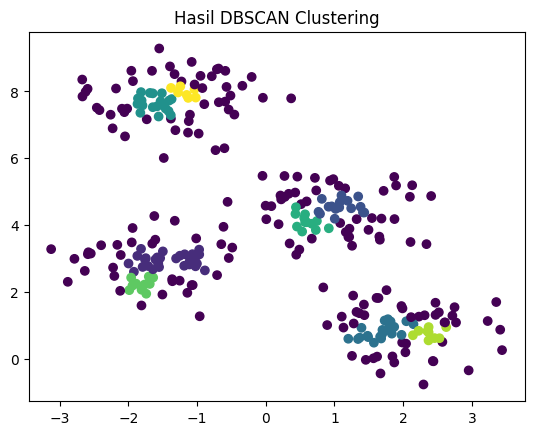

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
# Membuat data contoh
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60,
random_state=0)
# Menggunakan DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
labels = dbscan.fit_predict(X)
# Visualisasi hasil clustering
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Hasil DBSCAN Clustering")
plt.show()

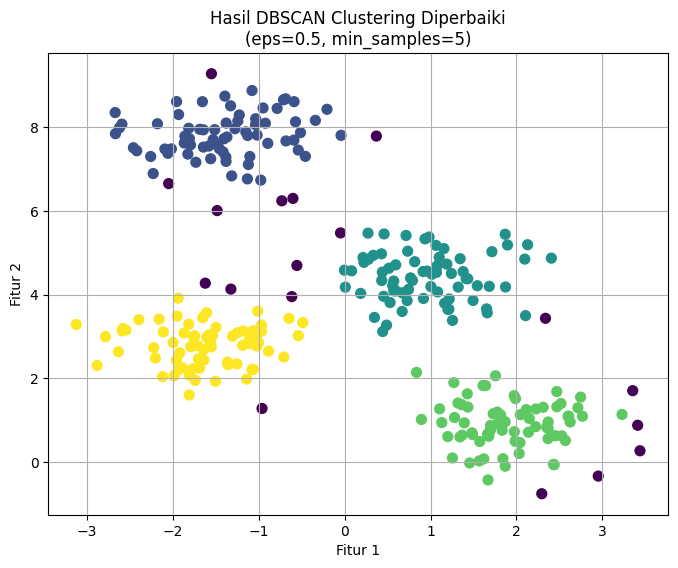

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# 1. Generate data contoh yang sama seperti di modul (halaman 8)
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Parameter Terbaik Hasil Eksperimen (Silakan dicoba)
# Kita naikkan eps dari 0.3 menjadi 0.5 agar radius lebih luas
# Kita turunkan min_samples dari 10 menjadi 5 agar kluster lebih mudah terbentuk
eps_terbaik = 0.5
min_samples_terbaik = 5

# 3. Menjalankan DBSCAN Perbaikan
dbscan_opt = DBSCAN(eps=eps_terbaik, min_samples=min_samples_terbaik)
labels_opt = dbscan_opt.fit_predict(X)

# 4. Visualisasi Hasil Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_opt, cmap='viridis', s=50)
plt.title(f"Hasil DBSCAN Clustering Diperbaiki\n(eps={eps_terbaik}, min_samples={min_samples_terbaik})")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.grid(True)
plt.show()

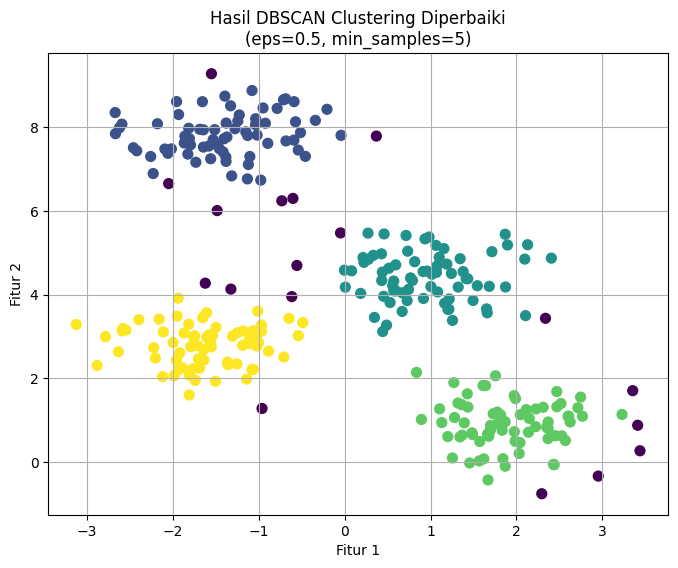

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Kita naikkan eps dari 0.3 menjadi 0.5 agar radius lebih luas
# Kita turunkan min_samples dari 10 menjadi 5 agar kluster lebih mudah terbentuk
eps_terbaik = 0.5
min_samples_terbaik = 5

# 3. Menjalankan DBSCAN
dbscan_opt = DBSCAN(eps=eps_terbaik, min_samples=min_samples_terbaik)
labels_opt = dbscan_opt.fit_predict(X)

# 4. Visualisasi Hasil Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_opt, cmap='viridis', s=50)
plt.title(f"Hasil DBSCAN Clustering Diperbaiki\n(eps={eps_terbaik}, min_samples={min_samples_terbaik})")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.grid(True)
plt.show()

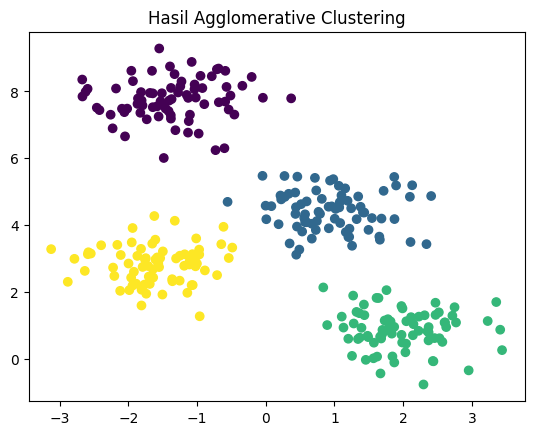

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# Menggunakan Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=4)
agg_labels = agg_clust.fit_predict(X)
# Visualisasi hasil clustering
plt.scatter(X[:, 0], X[:, 1], c=agg_labels,
cmap='viridis')
plt.title("Hasil Agglomerative Clustering")
plt.show()